# PG1 example

Note: data are directly downloaded from the paper - not MAVEdb

## Process the raw data from the paper (The Genetic Landscape of a Metabolic Interaction) .xlsx sheet to a .csv
only analyze info needed for the [DMS_internal_spreadsheet](https://docs.google.com/spreadsheets/d/1M1dKN0wpvE2sKDt4hwrIsTBS1r1HbBObUxjO4LNOQ64/edit?gid=560024392#gid=560024392).

DMS_id consists of Uniprot-ID_first-author_year-of-publication

First we search for whether a paper's DMS data have already been incorporated into the [MAVEdb website](https://www.mavedb.org/). If so, the data are already formatted and can be processed using existing functions.

In [1]:
import sys
sys.path.append("..")
sys.path.append("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/DMS_assays/archives")

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
import numpy as np

from scripts.dms_preprocessing_utils import process_mavedb_missense, hgvs_to_1aa, make_wt, check_wt # functions can be reused

SyntaxError: invalid syntax (<fstring>, line 1)

In [2]:
DMS_id = "DYR_ECOLI_Nguyen_2023"
WT_SEQ = "MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR"

raw_excel = f"../raw_data/{DMS_id}/542639_file03.xlsx"
csv_out = f"../preprocessed_substitutions/{DMS_id}.csv"

len(WT_SEQ)

159

The df is only called df_mave, not from MAVEdb

In [3]:
df_mave = pd.read_excel(raw_excel)
df_mave

,Mutation,Avg Growth - WT TYMS,Std Growth - WT TYMS,Avg Growth - Q33S TYMS,Std Growth - Q33S TYMS,Avg Growth - R166Q TYMS,R166Q_gr_std
0,M1G,NaN,NaN,NaN,NaN,NaN,NaN
1,M1A,NaN,NaN,NaN,NaN,NaN,NaN
2,M1V,NaN,NaN,0.94,0.01,NaN,NaN
3,M1L,NaN,NaN,NaN,NaN,NaN,NaN
4,M1M,1.00,0.00,1.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...
3334,R159C,0.99,0.02,1.01,0.02,1.05,0.03
3335,R159N,1.03,0.00,1.05,0.01,1.02,0.03
3336,R159Q,1.07,0.02,1.04,0.01,1.02,0.02
3337,R159P,1.06,0.01,1.05,0.01,1.04,0.01


In [4]:
df_mave = df_mave.dropna(subset=['Avg Growth - WT TYMS'])
df_mave

,Mutation,Avg Growth - WT TYMS,Std Growth - WT TYMS,Avg Growth - Q33S TYMS,Std Growth - Q33S TYMS,Avg Growth - R166Q TYMS,R166Q_gr_std
4,M1M,1.00,0.00,1.00,0.00,1.00,0.00
21,I2G,0.42,0.04,0.24,0.12,0.94,0.02
22,I2A,0.72,0.04,0.71,0.05,1.07,0.02
23,I2V,0.90,0.02,0.85,0.03,1.07,0.03
24,I2L,0.92,0.00,0.91,0.01,1.04,0.02
...,...,...,...,...,...,...,...
3334,R159C,0.99,0.02,1.01,0.02,1.05,0.03
3335,R159N,1.03,0.00,1.05,0.01,1.02,0.03
3336,R159Q,1.07,0.02,1.04,0.01,1.02,0.02
3337,R159P,1.06,0.01,1.05,0.01,1.04,0.01


We're saving all the columns into the .csv but only using `Avg Growth - WT TYMS` for model scoring

`region_mutated` is 2-159

Count the total number of 
- mutations
- nonsynonymous mutations and not nonsense mutations

Except with genomic language models, we're only interested in missense mutations (nonsynonymous mutations and not nonsense mutations).

In [5]:
len(df_mave), ((df_mave["Mutation"].str[0] != df_mave["Mutation"].str[-1]) & (df_mave["Mutation"].str[-1] != "*")).sum()

(3192, np.int64(2916))

To get the exact wild-type sequence, take the mutation column and output the sequence. **This is a recommended way of getting the wild-type sequence.**

Here, we assume that each position has been mutated, if not, the function outputs X as this location. 

In [6]:
make_wt(df_mave["Mutation"])

'MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR'

In [7]:
df_mave_processed = df_mave.copy()
df_mave_processed.head()

,Mutation,Avg Growth - WT TYMS,Std Growth - WT TYMS,Avg Growth - Q33S TYMS,Std Growth - Q33S TYMS,Avg Growth - R166Q TYMS,R166Q_gr_std
4,M1M,1.00,0.00,1.00,0.00,1.00,0.00
21,I2G,0.42,0.04,0.24,0.12,0.94,0.02
22,I2A,0.72,0.04,0.71,0.05,1.07,0.02
23,I2V,0.90,0.02,0.85,0.03,1.07,0.03
24,I2L,0.92,0.00,0.91,0.01,1.04,0.02


This is to visualize the DMS score, here the avg growth.

np.float64(0.98)

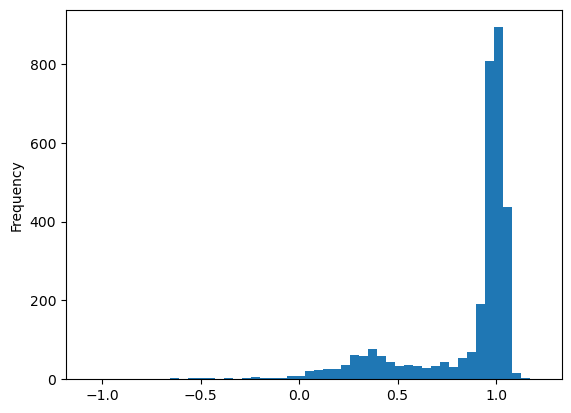

In [11]:
df_mave_processed["Avg Growth - WT TYMS"].plot.hist(bins=50)
df_mave_processed["Avg Growth - WT TYMS"].median()

Plot the distribution, colored by types of substitutions

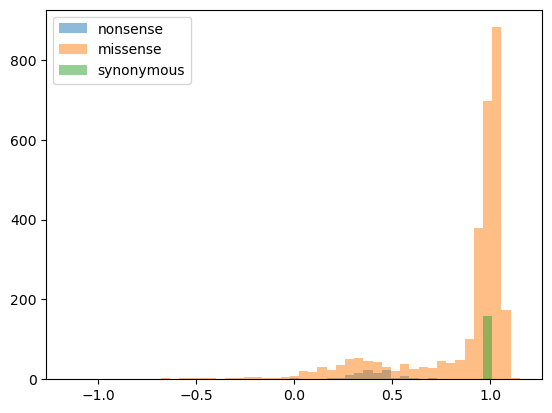

In [17]:
df_mave_synonymous = df_mave[df_mave["Mutation"].str[0] == df_mave["Mutation"].str[-1]]
df_mave_nonsense = df_mave[df_mave["Mutation"].str[-1] == "*"]
df_mave_missense = df_mave[(df_mave["Mutation"].str[0] != df_mave["Mutation"].str[-1]) & (df_mave["Mutation"].str[-1] != "*")]


bins = np.linspace(-1.15, 1.15, 50)

plt.hist(df_mave_nonsense["Avg Growth - WT TYMS"], bins, alpha=0.5, label='nonsense')
plt.hist(df_mave_missense["Avg Growth - WT TYMS"], bins, alpha=0.5, label='missense')
plt.hist(df_mave_synonymous["Avg Growth - WT TYMS"], bins, alpha=0.5, label='synonymous')
plt.legend(loc='upper left')
plt.show()

By looking at the distribution above, we manually chose 0.8 as the `DMS_binarization_cutoff`, which puts each data point into two `DMS_score_bin`. This is used for the AUC calculation.

The data range looks good, i.e., they do not just all look like the wild-type (score=1.0)

The DMS directionality is also +1, because the synonymous mutations have score=1.0 and the nonsense mutations have score<1.0. 

Saving the processed .csv file

In [8]:
df_mave_processed.to_csv(csv_out, index=False)

Most of the other blue colored columns in [DMS_internal_spreadsheet](https://docs.google.com/spreadsheets/d/1M1dKN0wpvE2sKDt4hwrIsTBS1r1HbBObUxjO4LNOQ64/edit?gid=560024392#gid=560024392) are filled out by reading papers and the red colored columns are filled out based on MSA info. The pdb file is generated from AF2 runs on O2.

*TO-DO: Regarding the new columns, additional code is needed to identify `domain_list_target_sequence` and `domain_list_full_sequence`.*

Further down the line, we used `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/DMS_assays/archives/notebooks/process_all_dms.ipynb` to collect the preprocessed substitutions as input to models. This can be done once all the data are processed.

it basically applies the function `DMS_file_cleanup()` to every csv in the preprocessed_substitutions folder.
Inside `DMS_file_cleanup()` :
- converts column names to mutant and DMS_score
- removes WT, synonymous, nonsense, and invalid mutants (not in AA vocab)
- checks that the mutant positions are within the expected range
- checks that the wild-type residues for each mutant match the expected wild-type sequence
- removes synonymous mutants from multi-mutants (e.g. M1M:A3C -> A3C), and then averages over identical mutants
- removes NaNs and infs from DMS_score
- multiplies DMS_score by the DMS directionality
- applies binarization threshold to make DMS_score_bin
- applies the mutant column to the wild-type sequence to get full mutated sequences (mutated_sequence)

## Run EVCouplings pipeline (on the wildtype sequence)
### Output:
- alignment (.a2m)
- EVcouplings model trained on the alignment
- other MSA info required for the [DMS_internal_spreadsheet](https://docs.google.com/spreadsheets/d/1M1dKN0wpvE2sKDt4hwrIsTBS1r1HbBObUxjO4LNOQ64/edit?gid=560024392#gid=560024392)
- weight of each sequence from the alignment - for downstream sampling during training
### Scripts:
1. /n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/EVCouplings/scripts/retrieve_MSA_example.sh
2. /n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/EVCouplings/scripts/retrieve_MSA.py
3. upcoming: check_msa.py
### Procedure:
1. If query sequence length < 100, start with bitscore = 0.7, 0.9, 1.0
2. If query sequence length = 101-500, start with bitscore = 0.3, 0.5, 0.8
3. If query sequence length > 501, start with bitscore = 0.1, 0.2, 0.3
### Goal:
A good MSA (similar to that from the EVmutation paper):
1. $>80\%$ of the columns covered by at least 70% of the sequences in the final alignment
2. Neff/L in 1-100, with some room for flexibility (150 is ok, <1 is ok after bitscore-based optimization)
3. If the two objectives above are conflicting, priority is given to 2
4. Additionally, for the purpose of PG2: each .m2a file should have
- more than 100 sequences
- less than 2M sequences
- separately list the design sequences
5. Additional postprocessing: remove alignments that align to $<50\%$ of the length of the target sequence (already done prior to alignment stats calculation by EVE code on AWS)

## Run AlphaFold2 (on the wildtype sequence)
### Input: 
fasta file is generated as in `MSA data prep (colabfold and EVCouplings)` in notebook: `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/notebooks_assays/Beltran_Lehner_2025.ipynb`

### Output:
- structure (ranked_0.pdb)

### Script:
overall running script: `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_AF2/run_get_AF2_structures.sh`
- can adjust the running parameters here: `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_AF2/get_AF2_structures.sh`
